In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
# sys.path.append("PATH TO loglikelihood_utils")

from QB_utils import sample_QB, QB_nll, QB_predictive_mean, QB_predictive_distribution
from ZOCN_utils import sample_ZOCN, ZOCN_nll, ZOCN_predictive_mean, ZOCN_predictive_distribution, ZOCN_randomized_pit
from BEINF_utils import sample_BEINF, BEINF_nll, BEINF_predictive_mean, BEINF_predictive_distribution, BEINF_randomized_pit
from ZOCTN_utils import sample_ZOCTN, ZOCTN_nll, ZOCTN_predictive_mean, ZOCTN_predictive_distribution, ZOCTN_randomized_pit
from ZOCSG_utils import sample_ZOCSG, ZOCSG_nll, ZOCSG_predictive_mean, ZOCSG_predictive_distribution, ZOCSG_randomized_pit
from ZOCTB_utils import sample_ZOCTB, ZOCTB_nll, ZOCTB_predictive_mean, ZOCTB_predictive_distribution, ZOCTB_randomized_pit

from simulation_utils import evaluate_models_on_simdata, simulate_dataset, MDR_sample, MDW_sample

# Simulate Samples

In [2]:
# Sampling ZOC-TN data
ZOCTN_beta_true = np.array([0.50, 0.005, -0.015, 0.01])
sigma_true, a_true, b_true = 0.25, 0.0, 1.50
ZOCTN_aux_params_true = np.array([sigma_true, np.exp(a_true), b_true])
_, zoctn_y, _, _ = simulate_dataset(sample_ZOCTN, 2000, 0, ZOCTN_beta_true, ZOCTN_aux_params_true, mixture_dist=False)

# Sampling ZOC-TB data
ZOCTB_beta_true = np.array([0.50, 0.005, -0.015, 0.01])
phi_true, u_true = 5.0, 0.2
ZOCTB_aux_params_true = np.array([phi_true, u_true])
_, zoctb_y, _, _ = simulate_dataset(sample_ZOCTB, 2000, 0, ZOCTB_beta_true, ZOCTB_aux_params_true, mixture_dist=False)

# Sampling ZOC-SG data
ZOCSG_beta_true = np.array([0.050, 0.005, -0.015, 0.01])
k_true, xi_true=10.0, 0.6
ZOCSG_aux_params_true = np.array([k_true, xi_true])
_, zocsg_y, _, _ = simulate_dataset(sample_ZOCSG, 2000, 0, ZOCSG_beta_true, ZOCSG_aux_params_true, mixture_dist=False)

# Sampling Right-Skew MD
mdr_beta_true = np.array([1.4, 0.1, 0.7, -0.05])
mdr_aux_params = [15.0]
_, md2_y, _, _ = simulate_dataset(MDR_sample, 2000, 0, mdr_beta_true, mdr_aux_params, mixture_dist=True)

# Sampling W-Shape MD
mdw_beta_true = np.array([0.0, 0.1, 0.05, -0.15])
mdw_centers = np.asarray([0.15, 0.50, 0.85])
mdw_kappas = np.array([5.0, 20.0, 5.0])
weight_strength, weight_center = 1.0, 0.80
md5_aux_params = [mdw_centers, mdw_kappas, weight_strength, weight_center]
_, md5_y, _, _ = simulate_dataset(MDW_sample, 2000, 0, mdw_beta_true, md5_aux_params, mixture_dist=True)

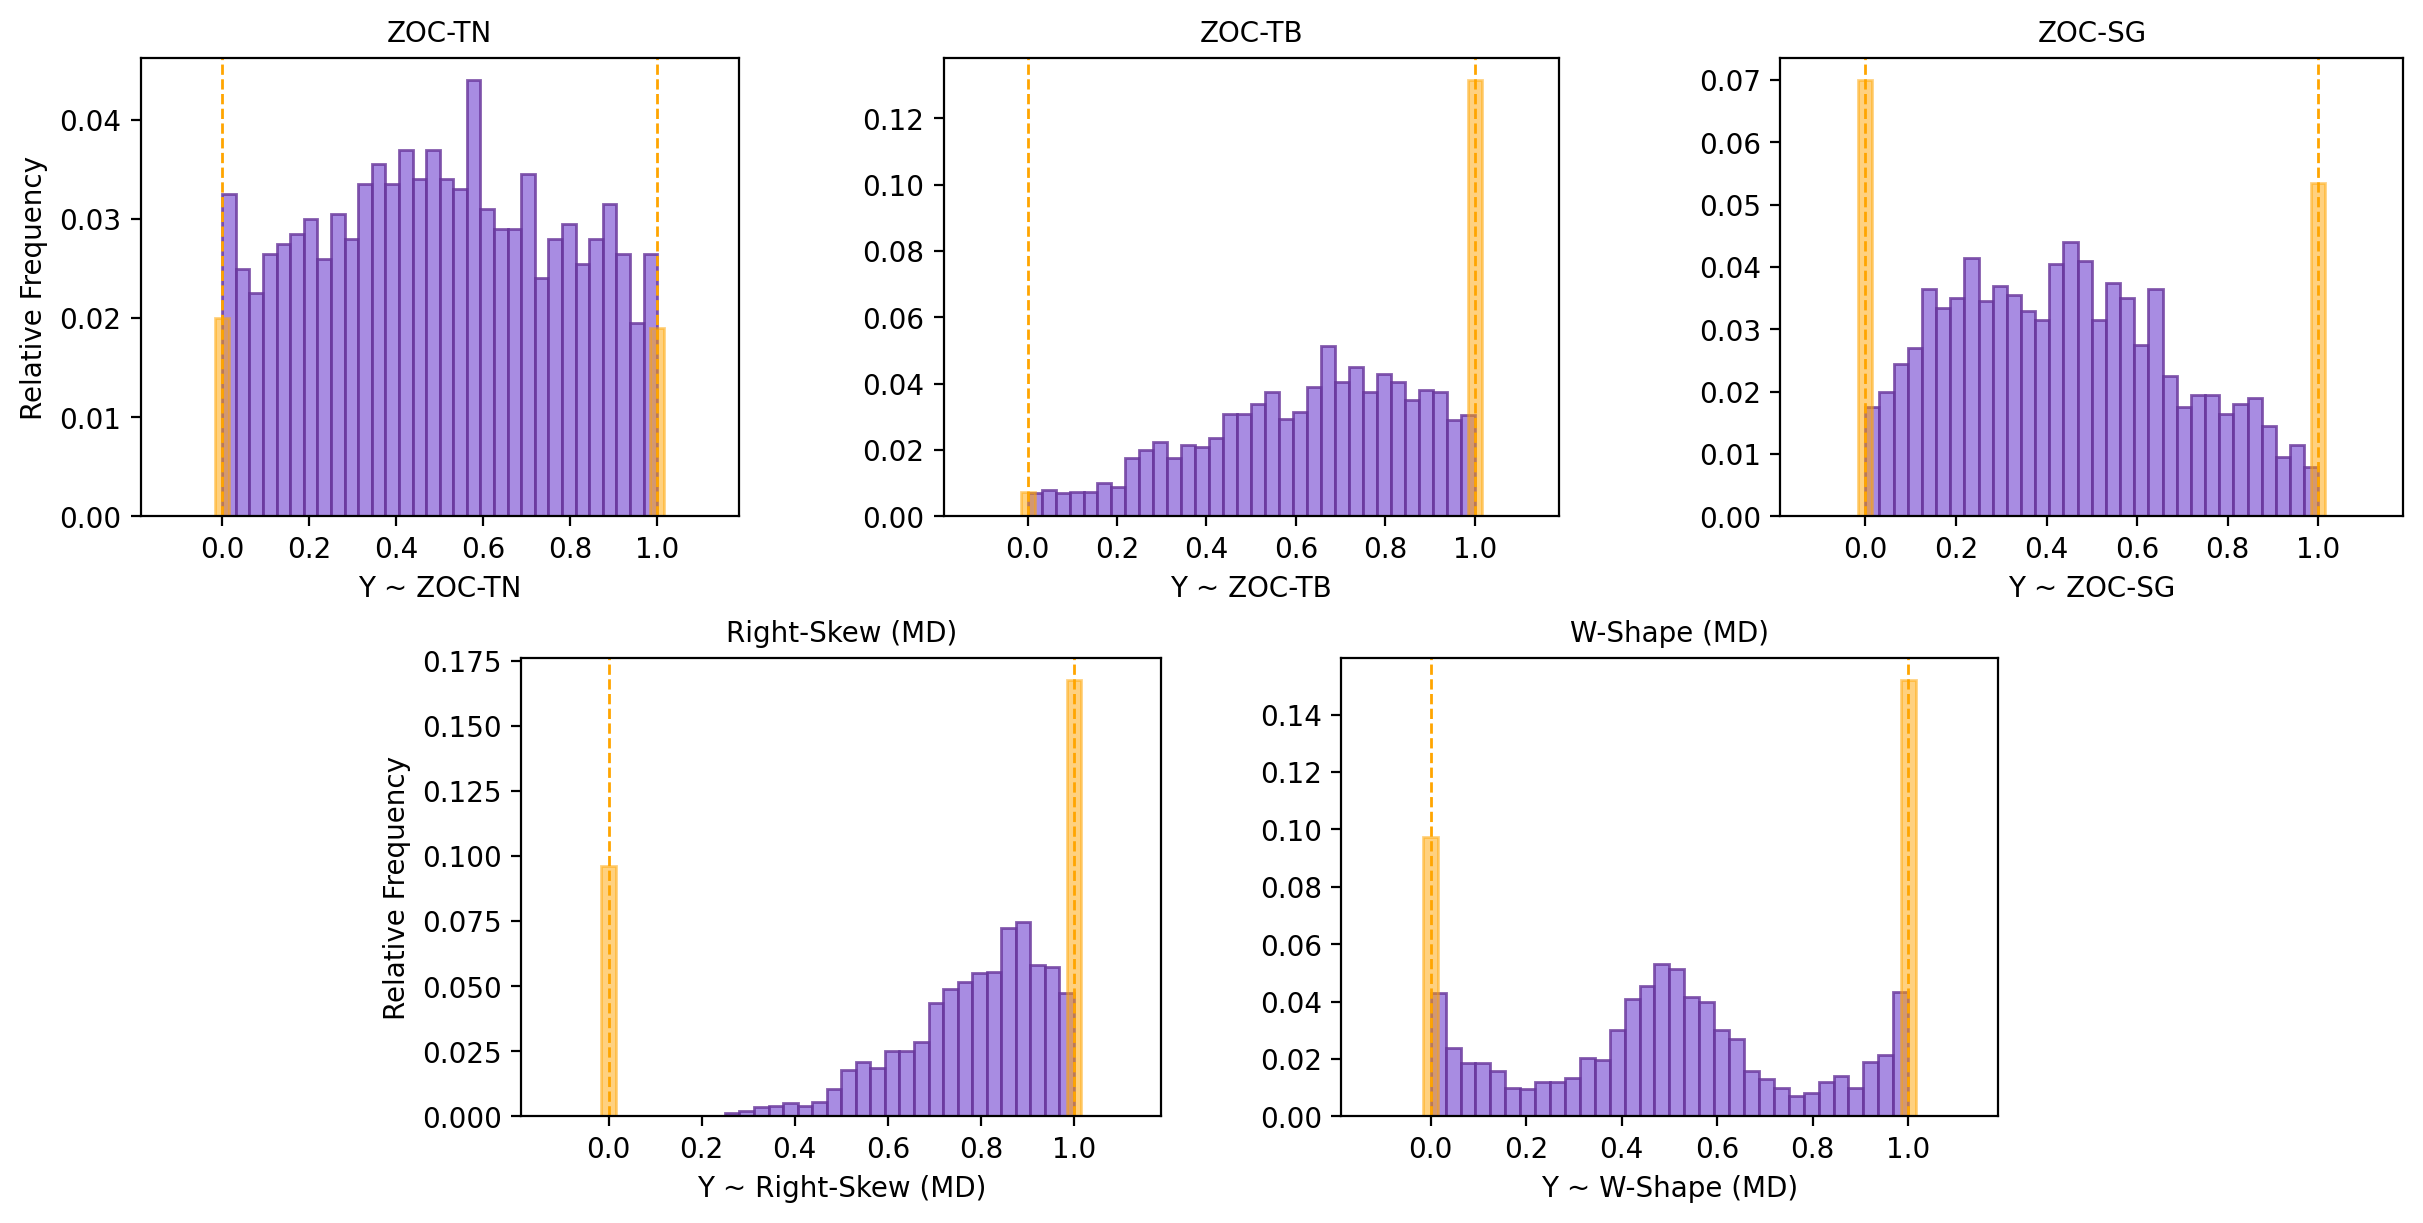

In [3]:
from simulation_utils import show_empirical_distributions

show_empirical_distributions(zoctn_y, zoctb_y, zocsg_y, md2_y, md5_y)

# Evaluate via MC Simulation

In [4]:
model_specs = {
    "QB": {
        "nll": QB_nll,
        "pred_mean": QB_predictive_mean,
        'sample_func': sample_QB,
        "pred_density": QB_predictive_distribution,
        "pit": None,
        "n_aux": 0,
    },
    "ZOC-N": {
        "nll": ZOCN_nll,
        "pred_mean": ZOCN_predictive_mean,
        'sample_func': sample_ZOCN,
        "pred_density": ZOCN_predictive_distribution,
        "pit": ZOCN_randomized_pit,
        "n_aux": 1,
    },
    "ZOC-SG": {
        "nll": ZOCSG_nll,
        "pred_mean": ZOCSG_predictive_mean,
        'sample_func': sample_ZOCSG,
        "pred_density": ZOCSG_predictive_distribution,
        "pit": ZOCSG_randomized_pit,
        "n_aux": 2,
    },
    "ZOC-TB": {
        "nll": ZOCTB_nll,
        "pred_mean": ZOCTB_predictive_mean,
        'sample_func': sample_ZOCTB,
        "pred_density": ZOCTB_predictive_distribution,
        "pit": ZOCTB_randomized_pit,
        "n_aux": 2,
    },
    "ZOC-TN": {
        "nll": ZOCTN_nll,
        "pred_mean": ZOCTN_predictive_mean,
        'sample_func': sample_ZOCTN,
        "pred_density": ZOCTN_predictive_distribution,
        "pit": ZOCTN_randomized_pit,
        "n_aux": 3,
    },
    "BE-INF": {
        "nll": BEINF_nll,
        "pred_mean": BEINF_predictive_mean,
        'sample_func': sample_BEINF,
        "pred_density": BEINF_predictive_distribution,
        "pit": BEINF_randomized_pit,
        "n_aux": 3,
    },
}

## ZOC-TN DGP
This code can be re-appropriated to evaluate the models across all DGPs.

In [5]:
import warnings

# Silence annoying deprecation warnings
warnings.filterwarnings(
    "ignore",
    message="The behavior of DataFrame concatenation with empty or all-NA entries is deprecated"
)

In [6]:
zoctn_results = pd.DataFrame(columns=['fitting_time', 'BIC', 'MSE', 'LS', 'CRPS', 'bd0_score', 'bd1_score'])
zoctn_pits = []

zoctb_results = pd.DataFrame(columns=['fitting_time', 'BIC', 'MSE', 'LS', 'CRPS', 'bd0_score', 'bd1_score'])
zoctb_pits = []

zocsg_results = pd.DataFrame(columns=['fitting_time', 'BIC', 'MSE', 'LS', 'CRPS', 'bd0_score', 'bd1_score'])
zocsg_pits = []

qb_results = pd.DataFrame(columns=['fitting_time', 'BIC', 'MSE', 'LS', 'CRPS', 'bd0_score', 'bd1_score'])

zocn_results = pd.DataFrame(columns=['fitting_time', 'BIC', 'MSE', 'LS', 'CRPS', 'bd0_score', 'bd1_score'])
zocn_pits = []

beinf_results = pd.DataFrame(columns=['fitting_time', 'BIC', 'MSE', 'LS', 'CRPS', 'bd0_score', 'bd1_score'])
beinf_pits = []

# This can take a while to run (30m)
for i in range(100):
    new_results = evaluate_models_on_simdata(model_specs, sample_ZOCTN, ZOCTN_predictive_distribution, beta_true=ZOCTN_beta_true, aux_params_true=ZOCTN_aux_params_true)
    results_df = new_results['results']
    pits = new_results['pits']

    new_zoctn_results = results_df.loc['ZOC-TN']
    zoctn_results = pd.concat([pd.DataFrame([new_zoctn_results], columns=zoctn_results.columns), zoctn_results], ignore_index=True)
    zoctn_pits.append(pits['ZOC-TN'])

    new_zoctb_results = results_df.loc['ZOC-TB']
    zoctb_results = pd.concat([pd.DataFrame([new_zoctb_results], columns=zoctb_results.columns), zoctb_results], ignore_index=True)
    zoctb_pits.append(pits['ZOC-TB'])

    new_zocsg_results = results_df.loc['ZOC-SG']
    zocsg_results = pd.concat([pd.DataFrame([new_zocsg_results], columns=zocsg_results.columns), zocsg_results], ignore_index=True)
    zocsg_pits.append(pits['ZOC-SG'])

    new_qb_results = results_df.loc['QB']
    qb_results = pd.concat([pd.DataFrame([new_qb_results], columns=qb_results.columns), qb_results], ignore_index=True)

    new_zocn_results = results_df.loc['ZOC-N']
    zocn_results = pd.concat([pd.DataFrame([new_zocn_results], columns=zocn_results.columns), zocn_results], ignore_index=True)
    zocn_pits.append(pits['ZOC-N'])

    new_beinf_results = results_df.loc['BE-INF']
    beinf_results = pd.concat([pd.DataFrame([new_beinf_results], columns=beinf_results.columns), beinf_results], ignore_index=True)
    beinf_pits.append(pits['BE-INF'])

In [7]:
tables = {
    "ZOCTN": zoctn_results,
    "ZOCTB": zoctb_results,
    "ZOCSG": zocsg_results,
    "QB": qb_results,
    "ZOCN": zocn_results,
    "BEINF": beinf_results,
}

summary_rows = []

for name, df in tables.items():
    # Keep only numeric columns for aggregation
    numeric_df = df.select_dtypes(include="number")

    mean_row = numeric_df.mean()
    std_row = numeric_df.std()

    mean_row.name = (name, "Mean")
    std_row.name = (name, "SD")

    summary_rows.append(mean_row)
    summary_rows.append(std_row)

# Combine into one dataframe
summary_df = pd.DataFrame(summary_rows)
summary_df

fitting_time          BIC       MSE        LS      CRPS  \
ZOCTN Mean      0.168880   466.359177  0.085074  0.213260  0.170079   
      SD        0.053569    43.321032  0.002712  0.026446  0.002754   
ZOCTB Mean      1.374549   467.675577  0.085056  0.216620  0.170069   
      SD        0.182508    42.995293  0.002706  0.026233  0.002731   
ZOCSG Mean     10.000732   586.816033  0.085050  0.277463  0.170602   
      SD       11.051014    41.231130  0.002716  0.024497  0.002927   
QB    Mean      0.039148  1410.424933  0.085084  0.693025  0.252434   
      SD        0.007670     1.702875  0.002715  0.001168  0.000970   
ZOCN  Mean      0.134875   580.817249  0.085035  0.276775  0.170453   
      SD        0.007344    40.905651  0.002710  0.024567  0.002882   
BEINF Mean      0.163532   478.306266  0.085063  0.219452  0.427146   
      SD        0.061398    43.394762  0.002706  0.026095  0.026856   

            bd0_score  bd1_score  
ZOCTN Mean   4.016616   4.132609  
      SD     2.079471   2.185593  
ZOCTB Mean   3.810678   3.961315  
      SD     1.747139   1.956229  
ZOCSG Mean  24.085293  29.802591  
      SD     4.827877   4.711063  
QB    Mean  23.031955  23.069225  
      SD     0.129570   0.128801  
ZOCN  Mean  26.821533  27.170131  
      SD     4.387420   4.459027  
BEINF Mean   4.670791   4.591151  
      SD     1.809952   1.825121

## Plotting PIT Reliability Residual Plots

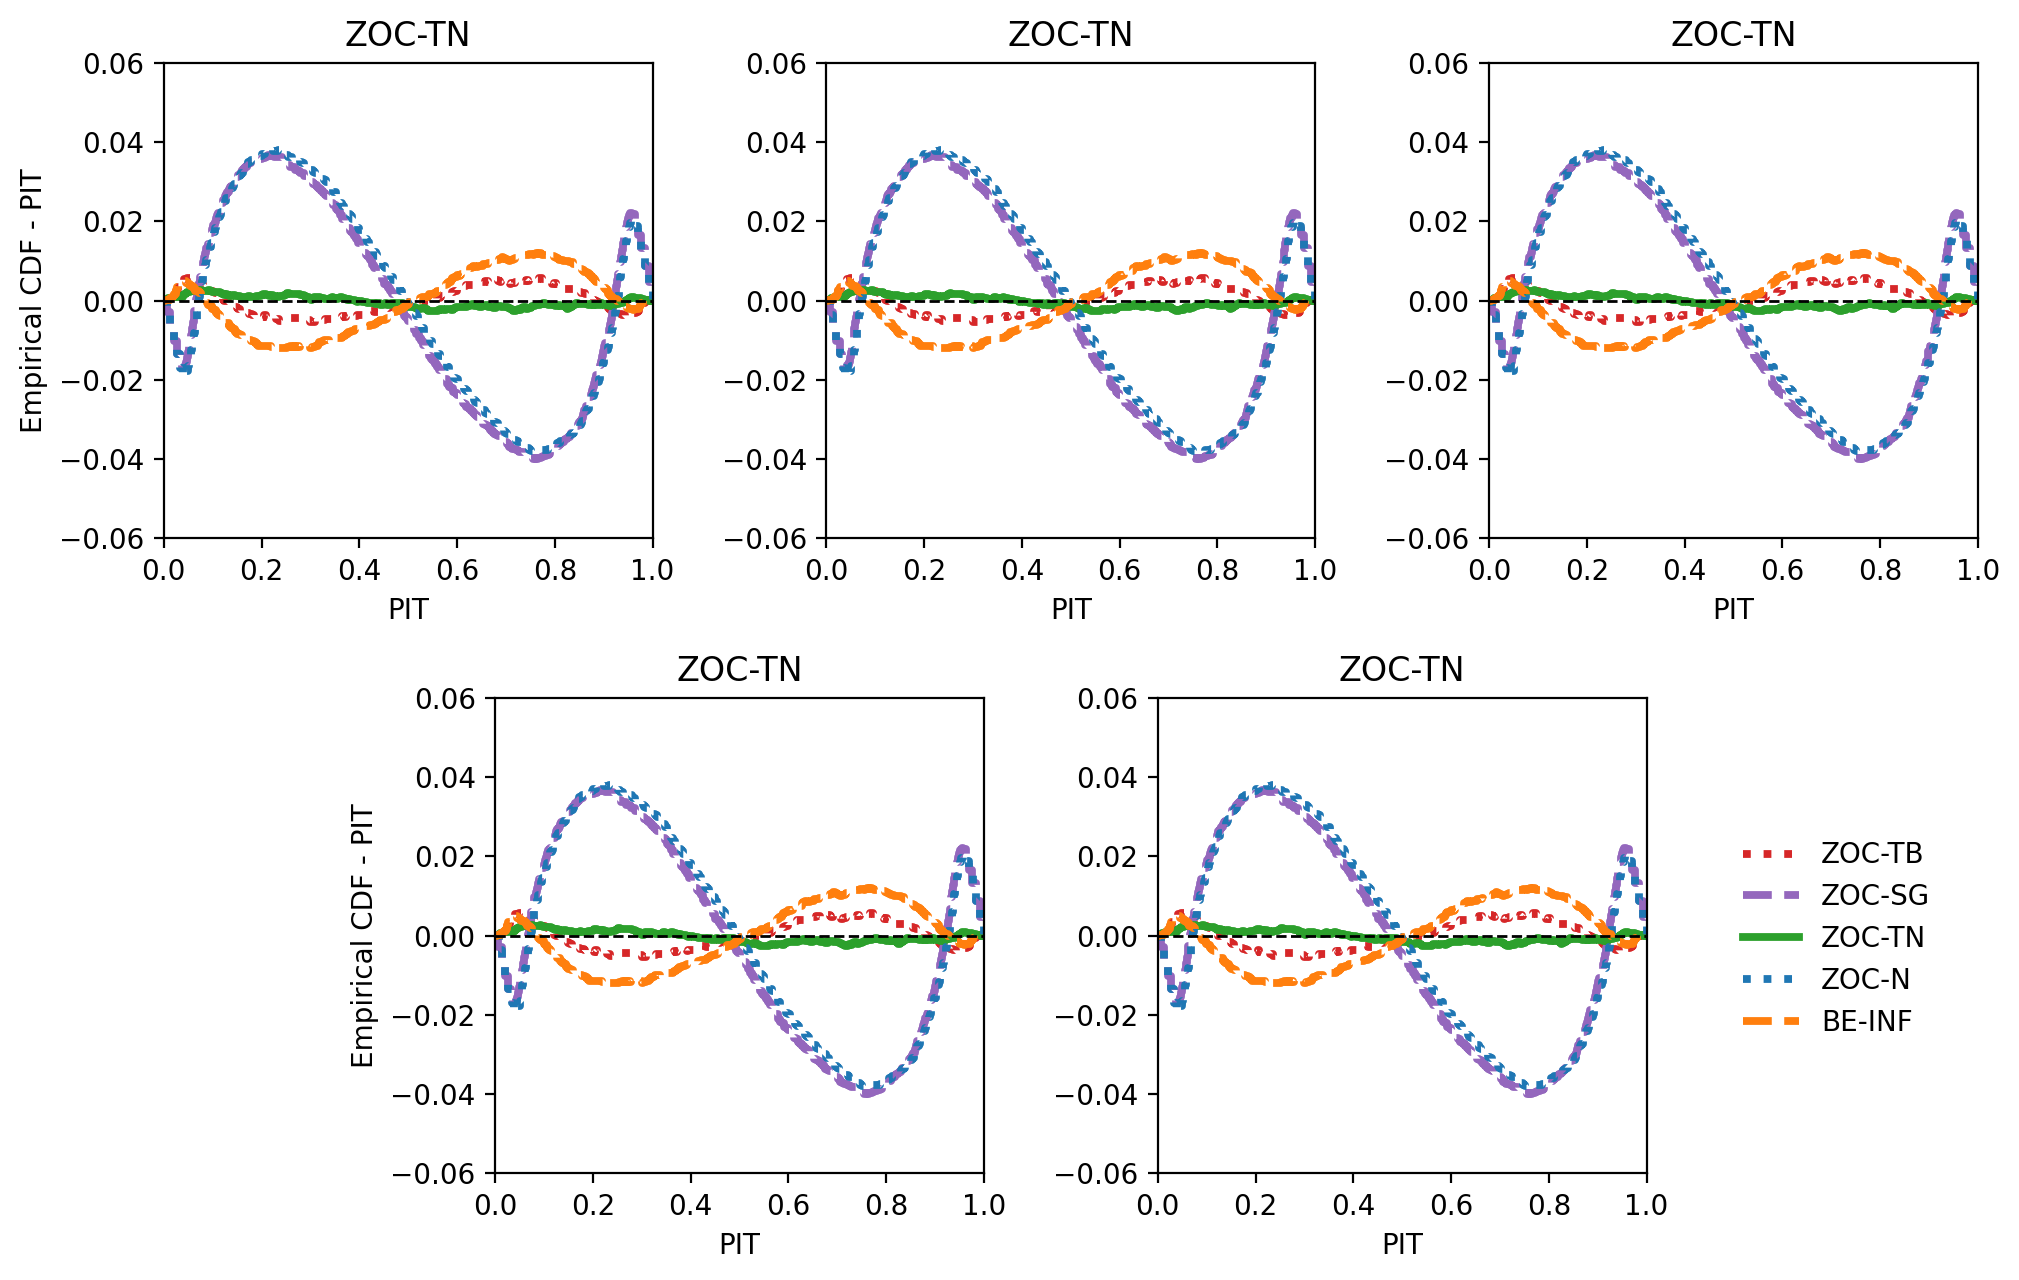

In [8]:
from simulation_utils import plot_pit_residuals_five_datasets

pit_by_dataset = {
    "ZOC-TN": {
        "ZOC-TB": np.concatenate(zoctb_pits),
        "ZOC-SG": np.concatenate(zocsg_pits),
        "ZOC-TN": np.concatenate(zoctn_pits),
        "ZOC-N": np.concatenate(zocn_pits),
        "BE-INF": np.concatenate(beinf_pits),
    },
    # We just plot the ZOC-TN DGP five times as a placeholder
    "ZOC-TN": {
        "ZOC-TB": np.concatenate(zoctb_pits),
        "ZOC-SG": np.concatenate(zocsg_pits),
        "ZOC-TN": np.concatenate(zoctn_pits),
        "ZOC-N": np.concatenate(zocn_pits),
        "BE-INF": np.concatenate(beinf_pits),
    },
    "ZOC-TN": {
        "ZOC-TB": np.concatenate(zoctb_pits),
        "ZOC-SG": np.concatenate(zocsg_pits),
        "ZOC-TN": np.concatenate(zoctn_pits),
        "ZOC-N": np.concatenate(zocn_pits),
        "BE-INF": np.concatenate(beinf_pits),
    },
    "ZOC-TN": {
        "ZOC-TB": np.concatenate(zoctb_pits),
        "ZOC-SG": np.concatenate(zocsg_pits),
        "ZOC-TN": np.concatenate(zoctn_pits),
        "ZOC-N": np.concatenate(zocn_pits),
        "BE-INF": np.concatenate(beinf_pits),
    },
    "ZOC-TN": {
        "ZOC-TB": np.concatenate(zoctb_pits),
        "ZOC-SG": np.concatenate(zocsg_pits),
        "ZOC-TN": np.concatenate(zoctn_pits),
        "ZOC-N": np.concatenate(zocn_pits),
        "BE-INF": np.concatenate(beinf_pits),
    },
}

model_colors = {
    'ZOC-TB': 'tab:red',
    'ZOC-SG': 'tab:purple',
    'ZOC-TN': 'tab:green',
    'ZOC-N':  'tab:blue',
    'BE-INF': 'tab:orange',
}
model_ls = {
    'ZOC-TB': ':',
    'ZOC-SG': '--',
    'ZOC-TN': '-',
    'ZOC-N':  ':',
    'BE-INF': '--',
}

fig, axes = plot_pit_residuals_five_datasets(
    pit_by_dataset=pit_by_dataset,
    # dataset_order=["ZOC-TN", "ZOC-TB", "ZOC-SG", "Right-Skew (MD)", "W-Shape (MD)"],
    dataset_order=["ZOC-TN", "ZOC-TN", "ZOC-TN", "ZOC-TN", "ZOC-TN"],
    model_colors=model_colors,
    model_ls=model_ls,
    figsize=(12, 6.5),
    show_counts=False,
)

plt.show()